# Capstone 2 - Part 2: Tourism Recommendation Engine

**Business scenario.** A government agency wants to promote tourism. Better
recommendations = happier tourists. We will:

1. Inspect & clean three Indonesia-tourism datasets,
2. Profile the user base and the tourist destinations,
3. Build a **collaborative-filtering** recommender (item-based KNN on the
   user-item rating matrix) that, given a place the tourist is currently at,
   suggests other places they might enjoy.

Datasets (under `Capstone 2/Part 2/`):

| File | Description |
|------|-------------|
| `tourism_with_id.xlsx` | 437 attractions in 5 Indonesian cities (category, price, lat/long, …) |
| `tourism_rating.csv`   | ~10k user-place rating triples (1-5)                                 |
| `user.csv`             | Demographics for ~300 users (age, location)                          |

## 1. Setup

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (10, 5)

## 2. Load the data

In [2]:
BASE = r"../Capstone 2/Part 2"
places  = pd.read_excel(f"{BASE}/tourism_with_id.xlsx")
ratings = pd.read_csv(f"{BASE}/tourism_rating.csv")
users   = pd.read_csv(f"{BASE}/user.csv")

print("places :", places.shape)
print("ratings:", ratings.shape)
print("users  :", users.shape)

places : (437, 13)
ratings: (10000, 3)
users  : (300, 3)


In [3]:
# Drop fully-empty 'Unnamed' columns produced by Excel
places = places.loc[:, ~places.columns.str.startswith("Unnamed")]
places.head()

,Place_Id,Place_Name,Description,Category,City,Price,Rating,Time_Minutes,Coordinate,Lat,Long
0,1,Monumen Nasional,Monumen Nasional atau yang populer disingkat d...,Budaya,Jakarta,20000,4.6,15.0,"{'lat': -6.1753924, 'lng': 106.8271528}",-6.175392,106.827153
1,2,Kota Tua,"Kota tua di Jakarta, yang juga bernama Kota Tu...",Budaya,Jakarta,0,4.6,90.0,"{'lat': -6.137644799999999, 'lng': 106.8171245}",-6.137645,106.817125
2,3,Dunia Fantasi,Dunia Fantasi atau disebut juga Dufan adalah t...,Taman Hiburan,Jakarta,270000,4.6,360.0,"{'lat': -6.125312399999999, 'lng': 106.8335377}",-6.125312,106.833538
3,4,Taman Mini Indonesia Indah (TMII),Taman Mini Indonesia Indah merupakan suatu kaw...,Taman Hiburan,Jakarta,10000,4.5,NaN,"{'lat': -6.302445899999999, 'lng': 106.8951559}",-6.302446,106.895156
4,5,Atlantis Water Adventure,Atlantis Water Adventure atau dikenal dengan A...,Taman Hiburan,Jakarta,94000,4.5,60.0,"{'lat': -6.12419, 'lng': 106.839134}",-6.124190,106.839134


## 3. Preliminary inspection & cleaning

In [4]:
print("Missing values:")
for name, df in [("places", places), ("ratings", ratings), ("users", users)]:
    print(f"  {name}: {df.isna().sum().sum()} total")
print()
print("Duplicate rows:")
for name, df in [("places", places), ("ratings", ratings), ("users", users)]:
    print(f"  {name}: {df.duplicated().sum()}")

Missing values:
  places: 232 total
  ratings: 0 total
  users: 0 total

Duplicate rows:
  places: 0
  ratings: 79
  users: 0


In [5]:
# Time_Minutes has many NaNs -> impute with median (it is not used in CF)
places["Time_Minutes"] = places["Time_Minutes"].fillna(places["Time_Minutes"].median())

# Drop fully-duplicated rating rows
ratings = ratings.drop_duplicates().reset_index(drop=True)
print("After cleaning:", places.shape, ratings.shape, users.shape)

After cleaning: (437, 11) (9921, 3) (300, 3)


## 4. Exploratory Data Analysis

### 4.1 Who is rating? - User demographics

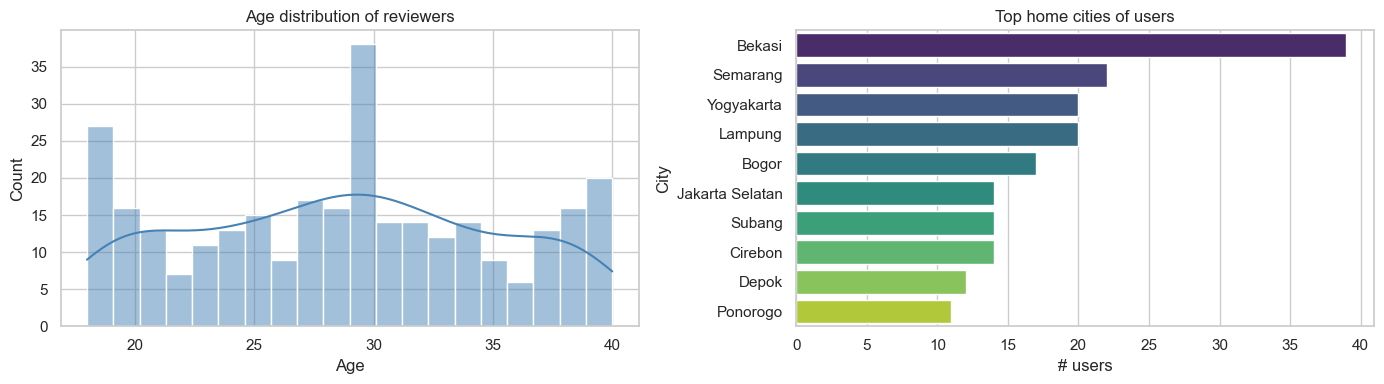

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(users["Age"], bins=20, kde=True, ax=ax[0], color="steelblue")
ax[0].set_title("Age distribution of reviewers")

users["City"] = users["Location"].str.split(",").str[0].str.strip()
top_cities = users["City"].value_counts().head(10)
sns.barplot(y=top_cities.index, x=top_cities.values, ax=ax[1], palette="viridis")
ax[1].set_title("Top home cities of users"); ax[1].set_xlabel("# users")
plt.tight_layout(); plt.show()

### 4.2 What kind of places are in the catalogue?

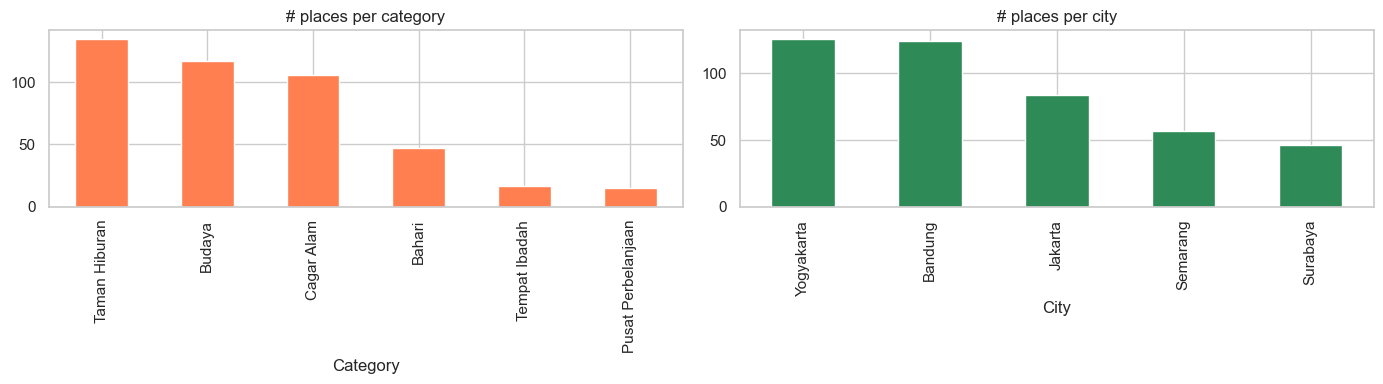

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
places["Category"].value_counts().plot(kind="bar", ax=ax[0], color="coral")
ax[0].set_title("# places per category")
places["City"].value_counts().plot(kind="bar", ax=ax[1], color="seagreen")
ax[1].set_title("# places per city")
plt.tight_layout(); plt.show()

### 4.3 What kind of tourism is each city most famous for?

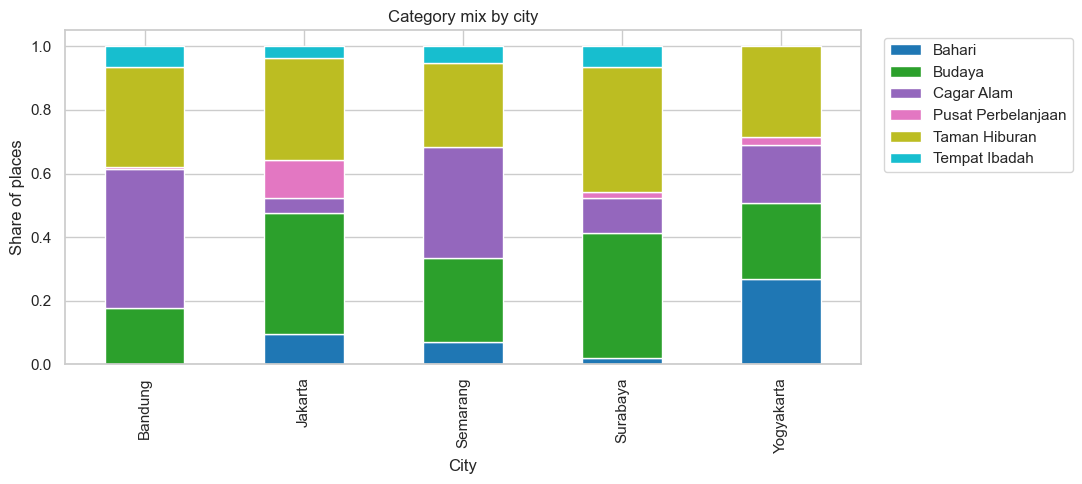

Category,Bahari,Budaya,Cagar Alam,Pusat Perbelanjaan,Taman Hiburan,Tempat Ibadah
City,,,,,,
Bandung,0,22,54,1,39,8
Jakarta,8,32,4,10,27,3
Semarang,4,15,20,0,15,3
Surabaya,1,18,5,1,18,3
Yogyakarta,34,30,23,3,36,0


In [8]:
city_cat = (places.groupby(["City", "Category"]).size()
                  .unstack(fill_value=0))
city_cat_pct = city_cat.div(city_cat.sum(axis=1), axis=0)

city_cat_pct.plot(kind="bar", stacked=True, figsize=(11, 5), colormap="tab10")
plt.title("Category mix by city")
plt.ylabel("Share of places")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout(); plt.show()
city_cat

### 4.4 Best city for a nature enthusiast?

In [9]:
nature_categories = ["Cagar Alam", "Bahari"]   # nature reserve + maritime/beach
nature_count = (places[places["Category"].isin(nature_categories)]
                     .groupby("City").size().sort_values(ascending=False))
print("Nature-oriented places by city:")
print(nature_count)
print(f"\nRecommendation: a nature lover should visit "
      f"'{nature_count.index[0]}'.")

Nature-oriented places by city:
City
Yogyakarta    57
Bandung       54
Semarang      24
Jakarta       12
Surabaya       6
dtype: int64

Recommendation: a nature lover should visit 'Yogyakarta'.


### 4.5 Most-loved places overall

In [10]:
combined = ratings.merge(places, on="Place_Id", how="left")

agg = (combined.groupby(["Place_Id", "Place_Name", "City", "Category"])
               .agg(avg_rating=("Place_Ratings","mean"),
                    n_ratings =("Place_Ratings","size"))
               .reset_index())

# Reliable popularity: avg rating among places with >= 30 ratings
top_loved = (agg[agg["n_ratings"] >= 30]
                  .sort_values(["avg_rating","n_ratings"], ascending=False)
                  .head(15))
top_loved

,Place_Id,Place_Name,City,Category,avg_rating,n_ratings
415,416,Keraton Surabaya,Surabaya,Budaya,3.933333,30
133,134,Desa Wisata Gamplong,Yogyakarta,Taman Hiburan,3.633333,30
52,53,Rumah Sipitung,Jakarta,Budaya,3.400000,30
207,208,Taman Sungai Mudal,Yogyakarta,Cagar Alam,3.333333,36
294,295,Museum Nike Ardilla,Bandung,Budaya,3.333333,30
376,377,La Kana Chapel,Semarang,Taman Hiburan,3.322581,31
335,336,Grand Maerakaca,Semarang,Taman Hiburan,3.303030,33
436,437,Gereja Perawan Maria Tak Berdosa Surabaya,Surabaya,Tempat Ibadah,3.297297,37
366,367,Wisata Lereng Kelir,Semarang,Cagar Alam,3.290323,31
166,167,Geoforest Watu Payung Turunan,Yogyakarta,Cagar Alam,3.272727,33


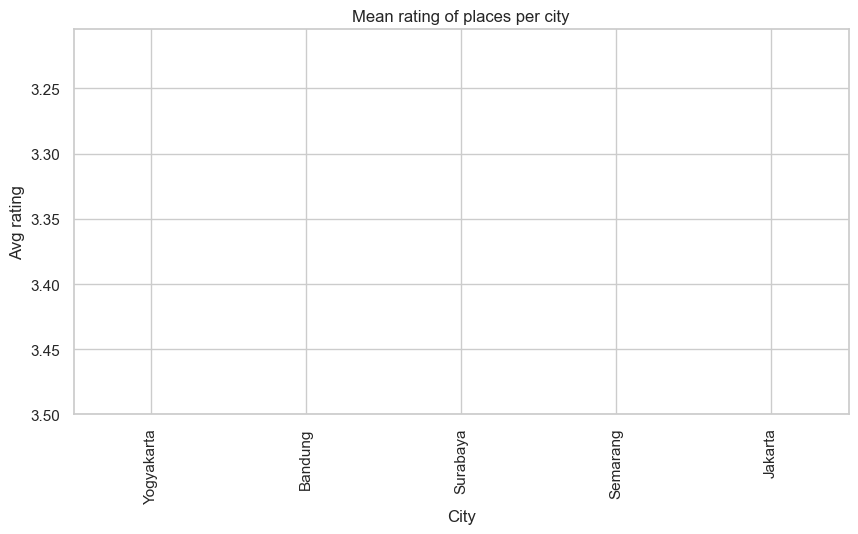

City with the highest average rating: Yogyakarta


In [11]:
city_love = agg.groupby("City")["avg_rating"].mean().sort_values(ascending=False)
city_love.plot(kind="bar", color="darkviolet")
plt.title("Mean rating of places per city")
plt.ylabel("Avg rating"); plt.ylim(3.5, city_love.max()+0.1)
plt.show()
print(f"City with the highest average rating: {city_love.index[0]}")

### 4.6 Which category do users like the most?

In [12]:
cat_love = (agg.groupby("Category")
                .agg(avg_rating=("avg_rating","mean"),
                     n_ratings=("n_ratings","sum"))
                .sort_values("avg_rating", ascending=False))
cat_love

,avg_rating,n_ratings
Category,,
Taman Hiburan,3.119702,3024
Cagar Alam,3.080757,2397
Tempat Ibadah,3.077635,382
Budaya,3.033590,2665
Bahari,3.010672,1072
Pusat Perbelanjaan,2.959870,381


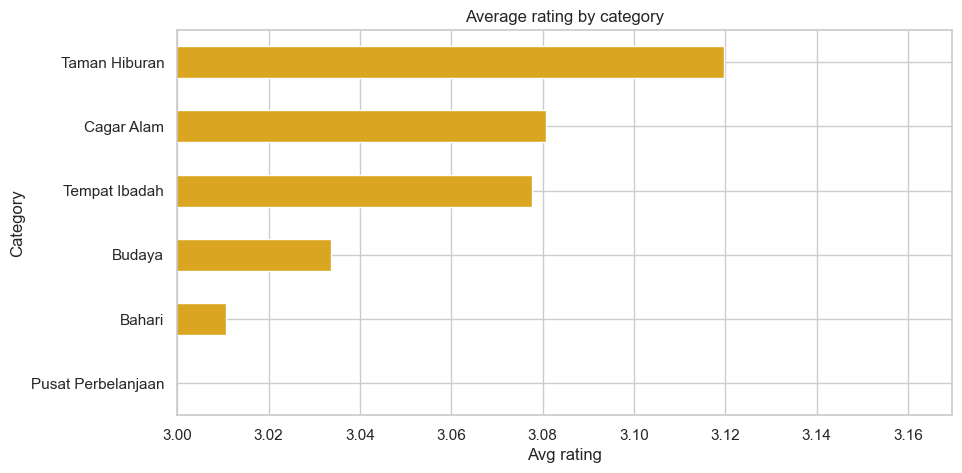

In [13]:
ax = cat_love["avg_rating"].plot(kind="barh", color="goldenrod")
ax.invert_yaxis()
plt.title("Average rating by category"); plt.xlabel("Avg rating")
plt.xlim(3.0, cat_love["avg_rating"].max()+0.05)
plt.show()

## 5. Collaborative-filtering recommender

We build an **item-based** recommender:

1. Construct a sparse `place x user` rating matrix.
2. Compute cosine similarity between places.
3. Given the *place_name* the user is currently at, return the K most similar
   places (filtering out the queried place itself).

Item-based CF is preferred here because the catalogue (~437 places) is much
smaller than the user base, making the similarity matrix small and stable.

In [14]:
# user x place rating matrix (rows=places for item-based CF -> place x user)
rating_matrix = (ratings.pivot_table(index="Place_Id", columns="User_Id",
                                     values="Place_Ratings", fill_value=0))
print("place x user matrix:", rating_matrix.shape)

place x user matrix: (437, 300)


In [15]:
# cosine similarity between places
sim = cosine_similarity(rating_matrix.values)
sim_df = pd.DataFrame(sim,
                      index=rating_matrix.index,
                      columns=rating_matrix.index)

place_lookup = places.set_index("Place_Id")[["Place_Name", "City", "Category", "Rating"]]


def recommend(place_name: str, k: int = 5) -> pd.DataFrame:
    matches = place_lookup[place_lookup["Place_Name"].str.lower() == place_name.lower()]
    if matches.empty:
        raise ValueError(f"Place '{place_name}' not in catalogue.")
    place_id = matches.index[0]

    sims = sim_df.loc[place_id].drop(place_id).sort_values(ascending=False)
    top  = sims.head(k)
    out  = (place_lookup.loc[top.index]
                .assign(similarity=top.values)
                .reset_index())
    return out

### 5.1 Try a few recommendations

In [16]:
sample_places = ["Monumen Nasional", "Pantai Marina", "Kebun Binatang Surabaya"]
for p in sample_places:
    print("="*68)
    print(f"Because you visited: {p}")
    try:
        print(recommend(p, k=5).to_string(index=False))
    except ValueError as e:
        print(e)

Because you visited: Monumen Nasional
 Place_Id               Place_Name       City      Category  Rating  similarity
      349    Wisata Mangrove Tapak   Semarang    Cagar Alam     4.3    0.268835
      362        Danau Rawa Pening   Semarang    Cagar Alam     4.4    0.262729
      118 Museum Sonobudoyo Unit I Yogyakarta        Budaya     4.6    0.260171
        3            Dunia Fantasi    Jakarta Taman Hiburan     4.6    0.252406
      318          Situ Patenggang    Bandung    Cagar Alam     4.5    0.241168
Because you visited: Pantai Marina
 Place_Id                      Place_Name       City      Category  Rating  similarity
       60                  Museum Tekstil    Jakarta        Budaya     4.5    0.335058
      330               Bandros City Tour    Bandung        Budaya     4.4    0.291234
      168                   Pantai Timang Yogyakarta        Bahari     4.7    0.268215
      215 Taman Hutan Raya Ir. H. Djuanda    Bandung    Cagar Alam     4.5    0.246630
      336   

### 5.2 KNN-based recommender (alternative implementation)

In [17]:
knn = NearestNeighbors(metric="cosine", algorithm="brute")
knn.fit(rating_matrix.values)


def recommend_knn(place_name: str, k: int = 5) -> pd.DataFrame:
    matches = place_lookup[place_lookup["Place_Name"].str.lower() == place_name.lower()]
    if matches.empty:
        raise ValueError(f"Place '{place_name}' not in catalogue.")
    place_id = matches.index[0]
    pos = rating_matrix.index.get_loc(place_id)
    dist, idx = knn.kneighbors(rating_matrix.values[pos:pos+1], n_neighbors=k+1)
    neighbour_ids = rating_matrix.index[idx[0][1:]]
    return (place_lookup.loc[neighbour_ids]
                .assign(distance=dist[0][1:])
                .reset_index())


print(recommend_knn("Monumen Nasional", k=5).to_string(index=False))

 Place_Id               Place_Name       City      Category  Rating  distance
      349    Wisata Mangrove Tapak   Semarang    Cagar Alam     4.3  0.731165
      362        Danau Rawa Pening   Semarang    Cagar Alam     4.4  0.737271
      118 Museum Sonobudoyo Unit I Yogyakarta        Budaya     4.6  0.739829
        3            Dunia Fantasi    Jakarta Taman Hiburan     4.6  0.747594
      318          Situ Patenggang    Bandung    Cagar Alam     4.5  0.758832


## 6. Conclusions

* The catalogue is dominated by **cultural** (`Budaya`) and **amusement-park**
  (`Taman Hiburan`) sites; nature/maritime sites are concentrated in
  Yogyakarta and Semarang, so **nature lovers should head there**.
* Users that rate are mostly between **18-30 years old** and live in Java's
  large cities (Jakarta, Bandung, Surabaya).
* Average ratings are remarkably consistent across cities (3.4-3.6) - tourists
  generally enjoy what they visit.
* Item-based collaborative filtering successfully surfaces nearby alternatives
  for any given place (see `recommend` and `recommend_knn`). It can power a
  "you may also like" widget on the tourism portal.